
# Stress Testing

## Credit Risk Intelligence Lab

This notebook closes the first complete version of the **Credit Risk Intelligence Lab** by adding a stress testing and scenario analysis layer.

The previous notebooks built the analytical foundation of the project:

1. Exploratory credit risk analysis.
2. Feature engineering and preprocessing.
3. Probability of Default model.
4. Unsupervised risk segmentation.
5. Anomaly detection.
6. Model interpretability.
7. Portfolio-level risk reporting.

This notebook asks a final portfolio risk question: **what happens to expected loss if credit conditions deteriorate?**

In credit risk management, a model estimate is only one view of risk. A portfolio should also be examined under adverse scenarios. Stress testing helps evaluate sensitivity to increases in probability of default, loss given default, exposure, and segment-specific deterioration.



## Notebook objectives

This notebook focuses on eight tasks:

1. Load the consolidated portfolio risk report.
2. Define base, mild, adverse, and severe stress scenarios.
3. Apply shocks to PD, LGD, and EAD.
4. Add extra stress to high-risk clusters, high-risk bands, and anomalous borrowers.
5. Calculate stressed expected loss under each scenario.
6. Compare portfolio-level risk across scenarios.
7. Analyze stress impact by risk band, cluster, and anomaly flag.
8. Save stress testing tables, figures, metadata, and a markdown stress report.

This notebook is not intended to be a regulatory stress testing framework. It is an analytical simulation layer that demonstrates how credit portfolio risk can be evaluated under alternative assumptions.


In [1]:

from pathlib import Path
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Project paths

The notebook is designed to run either from the project root or from the `notebooks/` directory.


In [2]:

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_FIGURES = REPORTS_DIR / "figures"
REPORTS_TABLES = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [DATA_PROCESSED, REPORTS_DIR, REPORTS_FIGURES, REPORTS_TABLES, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data path: {DATA_PROCESSED}")
print(f"Reports path: {REPORTS_DIR}")
print(f"Figures path: {REPORTS_FIGURES}")
print(f"Tables path: {REPORTS_TABLES}")


Project root: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab
Processed data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed
Reports path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports
Figures path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/figures
Tables path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/tables



## Load consolidated portfolio report

The preferred input is the output from notebook 07:

```text
data/processed/credit_risk_portfolio_report.csv
```

If that file is missing, the notebook falls back to:

```text
data/processed/credit_risk_segments.csv
```

The stress testing layer requires, at minimum, borrower-level predicted PD, exposure proxy, actual default label, and expected loss proxy.



In [3]:

portfolio_report_file = DATA_PROCESSED / "credit_risk_portfolio_report.csv"
segments_file = DATA_PROCESSED / "credit_risk_segments.csv"

if portfolio_report_file.exists():
    portfolio = pd.read_csv(portfolio_report_file, index_col=0)
    print("Loaded consolidated portfolio report from notebook 07.")
elif segments_file.exists():
    portfolio = pd.read_csv(segments_file, index_col=0)
    print("Loaded risk segments file as fallback input.")
else:
    raise FileNotFoundError(
        "Missing portfolio inputs. Run notebooks/04_unsupervised_risk_segmentation.ipynb "
        "and notebooks/07_portfolio_risk_reporting.ipynb before this notebook."
    )

portfolio.index = portfolio.index.astype(str)

required_columns = ["predicted_pd", "credit_amount", "actual_default"]

missing_required_columns = [col for col in required_columns if col not in portfolio.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

if "ead_proxy" not in portfolio.columns:
    portfolio["ead_proxy"] = portfolio["credit_amount"]

if "risk_cluster" not in portfolio.columns:
    portfolio["risk_cluster"] = "unknown_cluster"

if "risk_band" not in portfolio.columns:
    def assign_pd_band(pd_value: float) -> str:
        if pd.isna(pd_value):
            return "missing_pd"
        if pd_value < 0.20:
            return "low_risk"
        elif pd_value < 0.40:
            return "moderate_risk"
        elif pd_value < 0.60:
            return "elevated_risk"
        else:
            return "high_risk"
    portfolio["risk_band"] = portfolio["predicted_pd"].apply(assign_pd_band)

if "ensemble_anomaly_flag" not in portfolio.columns:
    portfolio["ensemble_anomaly_flag"] = 0

portfolio.head()


Loaded consolidated portfolio report from notebook 07.


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,age_bucket,duration_bucket,credit_amount_bucket,actual_default,predicted_pd,risk_cluster,ead_proxy,expected_loss_proxy,agg_cluster,ensemble_anomaly_score,ensemble_anomaly_flag,if_score_scaled,lof_score_scaled,top_positive_contributors,top_negative_contributors,risk_narrative,risk_band,exposure_bucket,flag_high_pd_high_exposure,flag_high_expected_loss,flag_anomalous_elevated_pd
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201,231.5278,9.0283,3.0000,1,1,25005,mid_career,long_term,high_amount,1,0.5487,1,8335,"2,058.0017",0,0.2145,0,0.4163,0.0128,NaN,NaN,NaN,elevated_risk,high_exposure,0,1,0
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,67.0000,6.6908,1.0000,0,0,3216,mid_career,short_term,low_amount,0,0.1170,0,804,42.3423,1,0.0010,0,0.0002,0.0017,NaN,NaN,NaN,low_risk,low_exposure,0,0,0
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201,149.1944,8.5890,3.0000,1,1,16113,early_career,long_term,high_amount,0,0.6783,1,5371,"1,639.4020",0,0.1913,0,0.3777,0.0048,NaN,NaN,NaN,high_risk,high_exposure,0,0,0
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201,110.8333,8.2918,3.0000,1,1,11970,early_career,long_term,high_amount,0,0.9167,1,3990,"1,645.9621",0,0.3607,1,0.7040,0.0174,NaN,NaN,NaN,high_risk,high_exposure,1,0,1
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201,176.8125,9.0464,4.0000,1,1,8487,young,very_long_term,high_amount,0,0.5706,1,8487,"2,179.1908",0,0.2260,0,0.4376,0.0145,NaN,NaN,NaN,elevated_risk,high_exposure,0,1,0



## Base portfolio assumptions

The expected loss framework is:

```text
Expected Loss = PD × LGD × EAD
```

Where:

- **PD** is probability of default.
- **LGD** is loss given default.
- **EAD** is exposure at default.

Because the German Credit dataset does not provide true LGD or EAD, the project uses:

- `predicted_pd` as model-based PD.
- `credit_amount` or `ead_proxy` as exposure proxy.
- A constant base LGD assumption of 45%.

These assumptions are simplified, but they allow the project to connect machine learning outputs with credit risk portfolio logic.


In [4]:

BASE_LGD = 0.45

portfolio["base_pd"] = portfolio["predicted_pd"].clip(0, 1)
portfolio["base_lgd"] = BASE_LGD
portfolio["base_ead"] = portfolio["ead_proxy"].clip(lower=0)
portfolio["base_expected_loss"] = portfolio["base_pd"] * portfolio["base_lgd"] * portfolio["base_ead"]

base_portfolio_summary = {
    "n_borrowers": int(len(portfolio)),
    "total_ead": float(portfolio["base_ead"].sum()),
    "average_pd": float(portfolio["base_pd"].mean()),
    "observed_default_rate": float(portfolio["actual_default"].mean()),
    "base_lgd": BASE_LGD,
    "base_expected_loss": float(portfolio["base_expected_loss"].sum()),
    "base_expected_loss_rate": float(portfolio["base_expected_loss"].sum() / portfolio["base_ead"].sum()),
}

base_portfolio_summary_df = pd.DataFrame(
    list(base_portfolio_summary.items()),
    columns=["metric", "value"],
)

base_portfolio_summary_df


,metric,value
0,n_borrowers,"1,000.0000"
1,total_ead,"3,271,258.0000"
2,average_pd,0.4319
3,observed_default_rate,0.3000
4,base_lgd,0.4500
5,base_expected_loss,"732,747.3497"
6,base_expected_loss_rate,0.2240



## Define stress scenarios

The scenarios below are deliberately simple and transparent.

Each scenario applies three types of shocks:

1. **General PD multiplier**: increases the probability of default across the portfolio.
2. **LGD level**: raises the assumed loss given default.
3. **EAD multiplier**: changes the exposure proxy.
4. **Targeted stress add-ons**: extra PD deterioration for high-risk clusters, high-risk bands, and anomalous borrowers.

The targeted add-ons make the stress test more interesting because not every borrower deteriorates in the same way.


In [5]:

stress_scenarios = pd.DataFrame(
    [
        {
            "scenario": "base",
            "pd_multiplier": 1.00,
            "lgd": 0.45,
            "ead_multiplier": 1.00,
            "high_risk_band_pd_addon": 0.00,
            "high_risk_cluster_pd_addon": 0.00,
            "anomaly_pd_addon": 0.00,
            "description": "Current model estimate with base LGD assumption.",
        },
        {
            "scenario": "mild_stress",
            "pd_multiplier": 1.15,
            "lgd": 0.50,
            "ead_multiplier": 1.00,
            "high_risk_band_pd_addon": 0.02,
            "high_risk_cluster_pd_addon": 0.01,
            "anomaly_pd_addon": 0.01,
            "description": "Moderate deterioration in borrower risk and recovery assumptions.",
        },
        {
            "scenario": "adverse_stress",
            "pd_multiplier": 1.30,
            "lgd": 0.55,
            "ead_multiplier": 1.03,
            "high_risk_band_pd_addon": 0.05,
            "high_risk_cluster_pd_addon": 0.03,
            "anomaly_pd_addon": 0.03,
            "description": "Adverse credit environment with stronger deterioration in risky profiles.",
        },
        {
            "scenario": "severe_stress",
            "pd_multiplier": 1.55,
            "lgd": 0.65,
            "ead_multiplier": 1.05,
            "high_risk_band_pd_addon": 0.08,
            "high_risk_cluster_pd_addon": 0.05,
            "anomaly_pd_addon": 0.05,
            "description": "Severe stress with broad PD deterioration and higher loss severity.",
        },
    ]
)

stress_scenarios


,scenario,pd_multiplier,lgd,ead_multiplier,high_risk_band_pd_addon,high_risk_cluster_pd_addon,anomaly_pd_addon,description
0,base,1.0000,0.4500,1.0000,0.0000,0.0000,0.0000,Current model estimate with base LGD assumption.
1,mild_stress,1.1500,0.5000,1.0000,0.0200,0.0100,0.0100,Moderate deterioration in borrower risk and re...
2,adverse_stress,1.3000,0.5500,1.0300,0.0500,0.0300,0.0300,Adverse credit environment with stronger deter...
3,severe_stress,1.5500,0.6500,1.0500,0.0800,0.0500,0.0500,Severe stress with broad PD deterioration and ...



## Identify vulnerable segments

To apply targeted stress, the notebook identifies:

- High-risk bands: `elevated_risk` and `high_risk`.
- High-risk clusters: clusters whose average PD is above the portfolio average.
- Anomalous borrowers: borrowers flagged by the anomaly detection layer.

This creates a stress design where riskier and more unusual profiles receive additional deterioration.


In [6]:

portfolio_avg_pd = portfolio["base_pd"].mean()

cluster_pd_summary = (
    portfolio
    .groupby("risk_cluster")
    .agg(
        borrowers=("base_pd", "size"),
        avg_pd=("base_pd", "mean"),
        observed_default_rate=("actual_default", "mean"),
        total_ead=("base_ead", "sum"),
        base_expected_loss=("base_expected_loss", "sum"),
    )
    .assign(
        ead_share=lambda x: x["total_ead"] / x["total_ead"].sum(),
        base_expected_loss_share=lambda x: x["base_expected_loss"] / x["base_expected_loss"].sum(),
    )
    .sort_values("avg_pd", ascending=False)
)

high_risk_clusters = cluster_pd_summary[
    cluster_pd_summary["avg_pd"] > portfolio_avg_pd
].index.tolist()

high_risk_bands = ["elevated_risk", "high_risk"]

print(f"Portfolio average PD: {portfolio_avg_pd:.4f}")
print(f"High-risk clusters: {high_risk_clusters}")
print(f"High-risk bands: {high_risk_bands}")

cluster_pd_summary


Portfolio average PD: 0.4319
High-risk clusters: [1]
High-risk bands: ['elevated_risk', 'high_risk']


,borrowers,avg_pd,observed_default_rate,total_ead,base_expected_loss,ead_share,base_expected_loss_share
risk_cluster,,,,,,,
1,282,0.5624,0.4255,1913969,"508,266.5752",0.5851,0.6936
0,718,0.3806,0.2507,1357289,"224,480.7744",0.4149,0.3064



## Stress testing engine

The function below applies each scenario to every borrower.

For each scenario:

1. Start with base PD.
2. Multiply PD by the scenario-level PD multiplier.
3. Add targeted PD stress for high-risk bands, high-risk clusters, and anomalies.
4. Cap stressed PD at 100%.
5. Apply scenario LGD.
6. Apply scenario EAD multiplier.
7. Calculate stressed expected loss.


In [7]:

def apply_stress_scenario(
    data: pd.DataFrame,
    scenario_row: pd.Series,
    high_risk_clusters: list,
    high_risk_bands: list,
) -> pd.DataFrame:
    stressed = data.copy()

    scenario_name = scenario_row["scenario"]

    stressed_pd = stressed["base_pd"] * scenario_row["pd_multiplier"]

    stressed_pd += np.where(
        stressed["risk_band"].isin(high_risk_bands),
        scenario_row["high_risk_band_pd_addon"],
        0.0,
    )

    stressed_pd += np.where(
        stressed["risk_cluster"].isin(high_risk_clusters),
        scenario_row["high_risk_cluster_pd_addon"],
        0.0,
    )

    stressed_pd += np.where(
        stressed["ensemble_anomaly_flag"] == 1,
        scenario_row["anomaly_pd_addon"],
        0.0,
    )

    stressed[f"{scenario_name}_pd"] = stressed_pd.clip(0, 1)
    stressed[f"{scenario_name}_lgd"] = float(scenario_row["lgd"])
    stressed[f"{scenario_name}_ead"] = stressed["base_ead"] * float(scenario_row["ead_multiplier"])
    stressed[f"{scenario_name}_expected_loss"] = (
        stressed[f"{scenario_name}_pd"]
        * stressed[f"{scenario_name}_lgd"]
        * stressed[f"{scenario_name}_ead"]
    )

    stressed[f"{scenario_name}_expected_loss_rate"] = (
        stressed[f"{scenario_name}_expected_loss"]
        / stressed[f"{scenario_name}_ead"].replace(0, np.nan)
    )

    return stressed

stress_results = portfolio.copy()

for _, scenario_row in stress_scenarios.iterrows():
    scenario_output = apply_stress_scenario(
        portfolio,
        scenario_row,
        high_risk_clusters=high_risk_clusters,
        high_risk_bands=high_risk_bands,
    )

    scenario_name = scenario_row["scenario"]
    scenario_cols = [
        f"{scenario_name}_pd",
        f"{scenario_name}_lgd",
        f"{scenario_name}_ead",
        f"{scenario_name}_expected_loss",
        f"{scenario_name}_expected_loss_rate",
    ]

    stress_results[scenario_cols] = scenario_output[scenario_cols]

stress_results.head()


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,age_bucket,duration_bucket,credit_amount_bucket,actual_default,predicted_pd,risk_cluster,ead_proxy,expected_loss_proxy,agg_cluster,ensemble_anomaly_score,ensemble_anomaly_flag,if_score_scaled,lof_score_scaled,top_positive_contributors,top_negative_contributors,risk_narrative,risk_band,exposure_bucket,flag_high_pd_high_exposure,flag_high_expected_loss,flag_anomalous_elevated_pd,base_pd,base_lgd,base_ead,base_expected_loss,base_expected_loss_rate,mild_stress_pd,mild_stress_lgd,mild_stress_ead,mild_stress_expected_loss,mild_stress_expected_loss_rate,adverse_stress_pd,adverse_stress_lgd,adverse_stress_ead,adverse_stress_expected_loss,adverse_stress_expected_loss_rate,severe_stress_pd,severe_stress_lgd,severe_stress_ead,severe_stress_expected_loss,severe_stress_expected_loss_rate
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201,231.5278,9.0283,3.0000,1,1,25005,mid_career,long_term,high_amount,1,0.5487,1,8335,"2,058.0017",0,0.2145,0,0.4163,0.0128,NaN,NaN,NaN,elevated_risk,high_exposure,0,1,0,0.5487,0.4500,"8,335.0000","2,058.0017",0.2469,0.6610,0.5000,"8,335.0000","2,754.6938",0.3305,0.7933,0.5500,"8,585.0500","3,745.7763",0.4363,0.9805,0.6500,"8,751.7500","5,577.5418",0.6373
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,67.0000,6.6908,1.0000,0,0,3216,mid_career,short_term,low_amount,0,0.1170,0,804,42.3423,1,0.0010,0,0.0002,0.0017,NaN,NaN,NaN,low_risk,low_exposure,0,0,0,0.1170,0.4500,804.0000,42.3423,0.0527,0.1346,0.5000,804.0000,54.1040,0.0673,0.1521,0.5500,828.1200,69.2955,0.0837,0.1814,0.6500,844.2000,99.5397,0.1179
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201,149.1944,8.5890,3.0000,1,1,16113,early_career,long_term,high_amount,0,0.6783,1,5371,"1,639.4020",0,0.1913,0,0.3777,0.0048,NaN,NaN,NaN,high_risk,high_exposure,0,0,0,0.6783,0.4500,"5,371.0000","1,639.4020",0.3052,0.8100,0.5000,"5,371.0000","2,175.3565",0.4050,0.9618,0.5500,"5,532.1300","2,926.3862",0.5290,1.0000,0.6500,"5,639.5500","3,665.7075",0.6500
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201,110.8333,8.2918,3.0000,1,1,11970,early_career,long_term,high_amount,0,0.9167,1,3990,"1,645.9621",0,0.3607,1,0.7040,0.0174,NaN,NaN,NaN,high_risk,high_exposure,1,0,1,0.9167,0.4500,"3,990.0000","1,645.9621",0.4125,1.0000,0.5000,"3,990.0000","1,995.0000",0.5000,1.0000,0.5500,"4,109.7000","2,260.3350",0.5500,1.0000,0.6500,"4,189.5000","2,723.1750",0.6500
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201,176.8125,9.0464,4.0000,1,1,8487,young,very_long_term,high_amount,0,0.5706,1,8487,"2,179.1908",0,0.2260,0,0.4376,0.0145,NaN,NaN,NaN,elevated_risk,high_exposure,0,1,0,0.5706,0.4500,"8,487.0000","2,179.1908",0.2568,0.6862,0.5000,"8,487.0000","2,911.8266",0.3431,0.8218,0.5500,"8,741.6100","3,950.9977",0.4520,1.0000,0.6500,"8,911.3500","5,792.3775",0.6500



## Portfolio-level stress results

This section summarizes the total impact of each scenario.

The key outputs are:

- Total exposure under scenario.
- Average stressed PD.
- Scenario LGD.
- Total expected loss.
- Expected loss rate.
- Increase in expected loss versus base.


In [8]:

portfolio_stress_summary_rows = []

base_expected_loss = stress_results["base_expected_loss"].sum()

for _, scenario_row in stress_scenarios.iterrows():
    scenario_name = scenario_row["scenario"]

    scenario_total_ead = stress_results[f"{scenario_name}_ead"].sum()
    scenario_total_el = stress_results[f"{scenario_name}_expected_loss"].sum()

    portfolio_stress_summary_rows.append(
        {
            "scenario": scenario_name,
            "description": scenario_row["description"],
            "total_ead": scenario_total_ead,
            "average_pd": stress_results[f"{scenario_name}_pd"].mean(),
            "median_pd": stress_results[f"{scenario_name}_pd"].median(),
            "lgd": scenario_row["lgd"],
            "total_expected_loss": scenario_total_el,
            "expected_loss_rate": scenario_total_el / scenario_total_ead,
            "expected_loss_increase_vs_base": scenario_total_el - base_expected_loss,
            "expected_loss_multiplier_vs_base": scenario_total_el / base_expected_loss,
        }
    )

portfolio_stress_summary = pd.DataFrame(portfolio_stress_summary_rows)

portfolio_stress_summary


,scenario,description,total_ead,average_pd,median_pd,lgd,total_expected_loss,expected_loss_rate,expected_loss_increase_vs_base,expected_loss_multiplier_vs_base
0,base,Current model estimate with base LGD assumption.,"3,271,258.0000",0.4319,0.4000,0.4500,"732,747.3497",0.2240,0.0000,1.0000
1,mild_stress,Moderate deterioration in borrower risk and re...,"3,271,258.0000",0.5016,0.4745,0.5000,"941,249.4489",0.2877,"208,502.0993",1.2845
2,adverse_stress,Adverse credit environment with stronger deter...,"3,369,395.7400",0.5593,0.5688,0.5500,"1,182,948.5007",0.3511,"450,201.1510",1.6144
3,severe_stress,Severe stress with broad PD deterioration and ...,"3,434,820.9000",0.6209,0.7026,0.6500,"1,564,056.0698",0.4554,"831,308.7201",2.1345


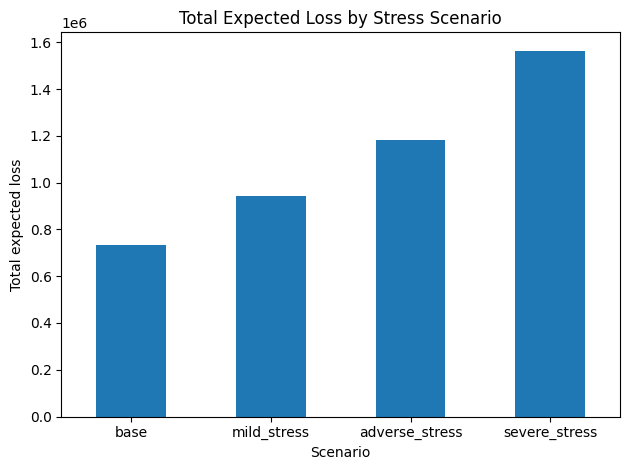

In [9]:

fig, ax = plt.subplots()

portfolio_stress_summary.set_index("scenario")["total_expected_loss"].plot(kind="bar", ax=ax)

ax.set_title("Total Expected Loss by Stress Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Total expected loss")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "08_total_expected_loss_by_scenario.png", dpi=150)
plt.show();


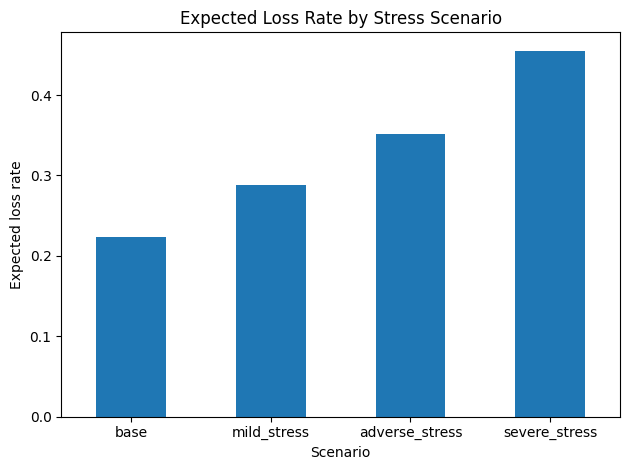

In [10]:

fig, ax = plt.subplots()

portfolio_stress_summary.set_index("scenario")["expected_loss_rate"].plot(kind="bar", ax=ax)

ax.set_title("Expected Loss Rate by Stress Scenario")
ax.set_xlabel("Scenario")
ax.set_ylabel("Expected loss rate")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "08_expected_loss_rate_by_scenario.png", dpi=150)
plt.show();



## Stress results by risk band

Risk band analysis shows which supervised PD groups absorb the largest stress impact.

This is useful for portfolio monitoring because a moderate number of high-risk borrowers can dominate stressed loss.


In [11]:

risk_band_stress_rows = []

for _, scenario_row in stress_scenarios.iterrows():
    scenario_name = scenario_row["scenario"]

    summary = (
        stress_results
        .groupby("risk_band")
        .agg(
            borrowers=("actual_default", "size"),
            total_ead=(f"{scenario_name}_ead", "sum"),
            avg_pd=(f"{scenario_name}_pd", "mean"),
            total_expected_loss=(f"{scenario_name}_expected_loss", "sum"),
            observed_default_rate=("actual_default", "mean"),
        )
        .assign(
            scenario=scenario_name,
            expected_loss_share=lambda x: x["total_expected_loss"] / x["total_expected_loss"].sum(),
            ead_share=lambda x: x["total_ead"] / x["total_ead"].sum(),
        )
        .reset_index()
    )

    risk_band_stress_rows.append(summary)

risk_band_stress_summary = pd.concat(risk_band_stress_rows, axis=0)

risk_band_stress_summary.head()


,risk_band,borrowers,total_ead,avg_pd,total_expected_loss,observed_default_rate,scenario,expected_loss_share,ead_share
0,elevated_risk,178,"647,615.0000",0.5027,"149,564.1918",0.3258,base,0.2041,0.1980
1,high_risk,322,"1,300,055.0000",0.7859,"473,754.6413",0.6242,base,0.6465,0.3974
2,low_risk,302,"776,816.0000",0.0986,"34,584.1392",0.0497,base,0.0472,0.2375
3,moderate_risk,198,"546,772.0000",0.3008,"74,844.3773",0.1313,base,0.1021,0.1671
0,elevated_risk,178,"647,615.0000",0.6017,"200,102.8207",0.3258,mild_stress,0.2126,0.1980


In [12]:

risk_band_el_pivot = risk_band_stress_summary.pivot(
    index="risk_band",
    columns="scenario",
    values="total_expected_loss",
)

risk_band_el_pivot


scenario,adverse_stress,base,mild_stress,severe_stress
risk_band,,,,
elevated_risk,"271,668.6451","149,564.1918","200,102.8207","400,056.9296"
high_risk,"722,500.8088","473,754.6413","598,469.5216","887,287.5375"
low_risk,"61,365.3168","34,584.1392","45,593.1545","90,872.3129"
moderate_risk,"127,413.7300","74,844.3773","97,083.9521","185,839.2898"


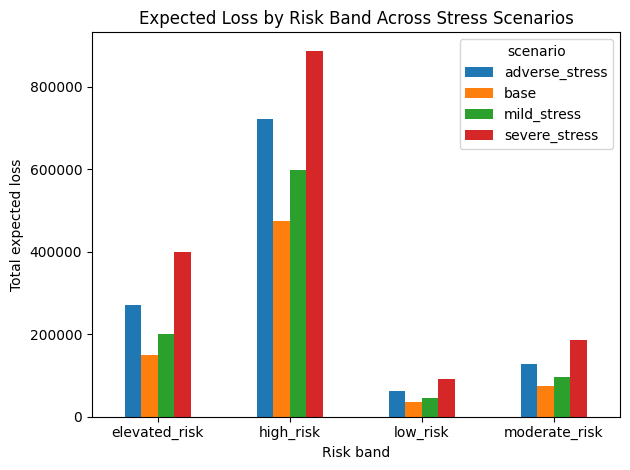

In [13]:

fig, ax = plt.subplots()

risk_band_el_pivot.plot(kind="bar", ax=ax)

ax.set_title("Expected Loss by Risk Band Across Stress Scenarios")
ax.set_xlabel("Risk band")
ax.set_ylabel("Total expected loss")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "08_expected_loss_by_risk_band_scenarios.png", dpi=150)
plt.show();



## Stress results by risk cluster

This section evaluates how each unsupervised risk segment behaves under stress.

A cluster may become important because it has high PD, high exposure, high LGD sensitivity, or a combination of these factors.


In [14]:

cluster_stress_rows = []

for _, scenario_row in stress_scenarios.iterrows():
    scenario_name = scenario_row["scenario"]

    summary = (
        stress_results
        .groupby("risk_cluster")
        .agg(
            borrowers=("actual_default", "size"),
            total_ead=(f"{scenario_name}_ead", "sum"),
            avg_pd=(f"{scenario_name}_pd", "mean"),
            total_expected_loss=(f"{scenario_name}_expected_loss", "sum"),
            observed_default_rate=("actual_default", "mean"),
            anomaly_rate=("ensemble_anomaly_flag", "mean"),
        )
        .assign(
            scenario=scenario_name,
            expected_loss_share=lambda x: x["total_expected_loss"] / x["total_expected_loss"].sum(),
            ead_share=lambda x: x["total_ead"] / x["total_ead"].sum(),
        )
        .reset_index()
    )

    cluster_stress_rows.append(summary)

cluster_stress_summary = pd.concat(cluster_stress_rows, axis=0)

cluster_stress_summary.head()


,risk_cluster,borrowers,total_ead,avg_pd,total_expected_loss,observed_default_rate,anomaly_rate,scenario,expected_loss_share,ead_share
0,0,718,"1,357,289.0000",0.3806,"224,480.7744",0.2507,0.0167,base,0.3064,0.4149
1,1,282,"1,913,969.0000",0.5624,"508,266.5752",0.4255,0.1348,base,0.6936,0.5851
0,0,718,"1,357,289.0000",0.4425,"290,403.2106",0.2507,0.0167,mild_stress,0.3085,0.4149
1,1,282,"1,913,969.0000",0.6521,"650,846.2383",0.4255,0.1348,mild_stress,0.6915,0.5851
0,0,718,"1,398,007.6700",0.4948,"369,074.5711",0.2507,0.0167,adverse_stress,0.3120,0.4149


In [15]:

cluster_el_pivot = cluster_stress_summary.pivot(
    index="risk_cluster",
    columns="scenario",
    values="total_expected_loss",
)

cluster_el_pivot


scenario,adverse_stress,base,mild_stress,severe_stress
risk_cluster,,,,
0,"369,074.5711","224,480.7744","290,403.2106","501,152.9745"
1,"813,873.9296","508,266.5752","650,846.2383","1,062,903.0953"


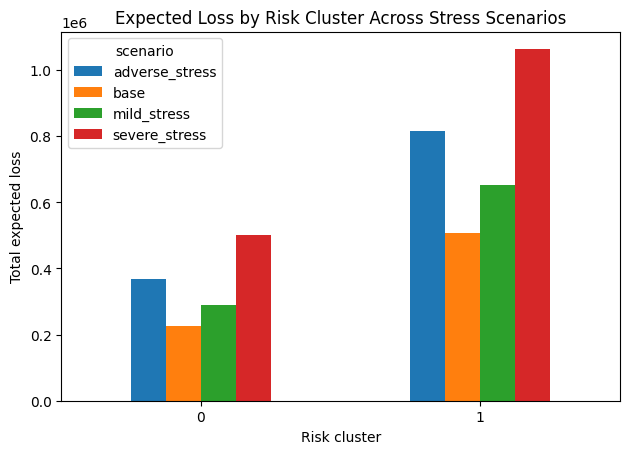

In [16]:

fig, ax = plt.subplots()

cluster_el_pivot.plot(kind="bar", ax=ax)

ax.set_title("Expected Loss by Risk Cluster Across Stress Scenarios")
ax.set_xlabel("Risk cluster")
ax.set_ylabel("Total expected loss")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "08_expected_loss_by_cluster_scenarios.png", dpi=150)
plt.show();



## Anomaly stress impact

This section compares normal and anomalous borrower profiles under each scenario.

Anomalies receive an additional PD shock in the scenario design because unusual borrower profiles may be harder to assess and monitor.


In [17]:

anomaly_stress_rows = []

for _, scenario_row in stress_scenarios.iterrows():
    scenario_name = scenario_row["scenario"]

    summary = (
        stress_results
        .groupby("ensemble_anomaly_flag")
        .agg(
            borrowers=("actual_default", "size"),
            total_ead=(f"{scenario_name}_ead", "sum"),
            avg_pd=(f"{scenario_name}_pd", "mean"),
            total_expected_loss=(f"{scenario_name}_expected_loss", "sum"),
            observed_default_rate=("actual_default", "mean"),
        )
        .assign(
            scenario=scenario_name,
            expected_loss_share=lambda x: x["total_expected_loss"] / x["total_expected_loss"].sum(),
            ead_share=lambda x: x["total_ead"] / x["total_ead"].sum(),
        )
        .reset_index()
    )

    summary["profile_type"] = np.where(
        summary["ensemble_anomaly_flag"] == 1,
        "anomalous_profile",
        "normal_profile",
    )

    anomaly_stress_rows.append(summary)

anomaly_stress_summary = pd.concat(anomaly_stress_rows, axis=0)

anomaly_stress_summary


,ensemble_anomaly_flag,borrowers,total_ead,avg_pd,total_expected_loss,observed_default_rate,scenario,expected_loss_share,ead_share,profile_type
0,0,950,"2,866,952.0000",0.4194,"600,467.2153",0.2895,base,0.8195,0.8764,normal_profile
1,1,50,"404,306.0000",0.6684,"132,280.1344",0.5000,base,0.1805,0.1236,anomalous_profile
0,0,950,"2,866,952.0000",0.4878,"774,705.5450",0.2895,mild_stress,0.8231,0.8764,normal_profile
1,1,50,"404,306.0000",0.7648,"166,543.9040",0.5000,mild_stress,0.1769,0.1236,anomalous_profile
0,0,950,"2,952,960.5600",0.5449,"978,192.6643",0.2895,adverse_stress,0.8269,0.8764,normal_profile
1,1,50,"416,435.1800",0.8342,"204,755.8364",0.5000,adverse_stress,0.1731,0.1236,anomalous_profile
0,0,950,"3,010,299.6000",0.6070,"1,302,881.4169",0.2895,severe_stress,0.8330,0.8764,normal_profile
1,1,50,"424,521.3000",0.8859,"261,174.6528",0.5000,severe_stress,0.1670,0.1236,anomalous_profile


In [18]:

anomaly_el_pivot = anomaly_stress_summary.pivot(
    index="profile_type",
    columns="scenario",
    values="total_expected_loss",
)

anomaly_el_pivot


scenario,adverse_stress,base,mild_stress,severe_stress
profile_type,,,,
anomalous_profile,"204,755.8364","132,280.1344","166,543.9040","261,174.6528"
normal_profile,"978,192.6643","600,467.2153","774,705.5450","1,302,881.4169"



## Sensitivity analysis: PD and LGD grid

Scenario analysis uses selected assumptions. Sensitivity analysis asks a broader question: how does total expected loss change across many combinations of PD and LGD shocks?

This grid applies:

- PD multipliers from 1.00 to 1.75.
- LGD values from 35% to 75%.

The output helps identify whether the portfolio is more sensitive to default frequency or loss severity.


In [19]:

pd_multipliers = np.arange(1.00, 1.80, 0.10)
lgd_values = np.arange(0.35, 0.80, 0.05)

sensitivity_rows = []

for pd_multiplier in pd_multipliers:
    for lgd in lgd_values:
        stressed_pd = (portfolio["base_pd"] * pd_multiplier).clip(0, 1)
        stressed_el = stressed_pd * lgd * portfolio["base_ead"]

        sensitivity_rows.append(
            {
                "pd_multiplier": round(float(pd_multiplier), 2),
                "lgd": round(float(lgd), 2),
                "total_expected_loss": float(stressed_el.sum()),
                "expected_loss_rate": float(stressed_el.sum() / portfolio["base_ead"].sum()),
                "expected_loss_multiplier_vs_base": float(stressed_el.sum() / base_expected_loss),
            }
        )

sensitivity_grid = pd.DataFrame(sensitivity_rows)

sensitivity_grid.head()


,pd_multiplier,lgd,total_expected_loss,expected_loss_rate,expected_loss_multiplier_vs_base
0,1.0000,0.3500,"569,914.6053",0.1742,0.7778
1,1.0000,0.4000,"651,330.9775",0.1991,0.8889
2,1.0000,0.4500,"732,747.3497",0.2240,1.0000
3,1.0000,0.5000,"814,163.7218",0.2489,1.1111
4,1.0000,0.5500,"895,580.0940",0.2738,1.2222


In [20]:

sensitivity_pivot = sensitivity_grid.pivot(
    index="lgd",
    columns="pd_multiplier",
    values="expected_loss_multiplier_vs_base",
)

sensitivity_pivot


pd_multiplier,1.0000,1.1000,1.2000,1.3000,1.4000,1.5000,1.6000,1.7000
lgd,,,,,,,,
0.3500,0.7778,0.8472,0.9044,0.9522,0.9932,1.0289,1.0604,1.0881
0.4000,0.8889,0.9682,1.0336,1.0883,1.1351,1.1759,1.2119,1.2435
0.4500,1.0000,1.0892,1.1628,1.2243,1.2770,1.3228,1.3634,1.3990
0.5000,1.1111,1.2102,1.2920,1.3603,1.4189,1.4698,1.5148,1.5544
0.5500,1.2222,1.3312,1.4212,1.4964,1.5607,1.6168,1.6663,1.7099
0.6000,1.3333,1.4523,1.5504,1.6324,1.7026,1.7638,1.8178,1.8653
0.6500,1.4444,1.5733,1.6796,1.7684,1.8445,1.9108,1.9693,2.0207
0.7000,1.5556,1.6943,1.8087,1.9044,1.9864,2.0577,2.1208,2.1762
0.7500,1.6667,1.8153,1.9379,2.0405,2.1283,2.2047,2.2723,2.3316


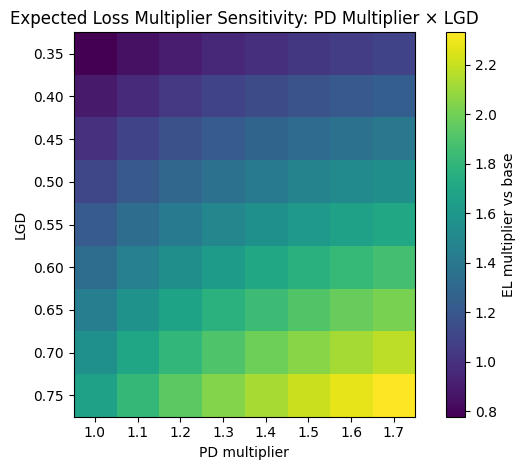

In [21]:
fig, ax = plt.subplots()

im = ax.imshow(sensitivity_pivot)

ax.set_title("Expected Loss Multiplier Sensitivity: PD Multiplier × LGD")
ax.set_xlabel("PD multiplier")
ax.set_ylabel("LGD")

ax.set_xticks(range(len(sensitivity_pivot.columns)))
ax.set_xticklabels(sensitivity_pivot.columns)

ax.set_yticks(range(len(sensitivity_pivot.index)))
ax.set_yticklabels([f"{value:.2f}" for value in sensitivity_pivot.index])

fig.colorbar(im, ax=ax, label="EL multiplier vs base")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "08_pd_lgd_sensitivity_heatmap.png", dpi=150)
plt.show()


## Top borrowers under severe stress

This section identifies borrowers with the highest expected loss under the severe stress scenario.

This table is useful for review prioritization. It should not be interpreted as an automatic rejection or collection list.


In [22]:

severe_scenario = "severe_stress"

top_severe_stress_borrowers = (
    stress_results
    .assign(
        severe_expected_loss=stress_results[f"{severe_scenario}_expected_loss"],
        severe_pd=stress_results[f"{severe_scenario}_pd"],
        severe_ead=stress_results[f"{severe_scenario}_ead"],
    )
    .sort_values("severe_expected_loss", ascending=False)
    .head(25)
)

review_columns = [
    "actual_default",
    "risk_band",
    "risk_cluster",
    "ensemble_anomaly_flag",
    "credit_amount",
    "duration_months",
    "age_years",
    "base_pd",
    "severe_pd",
    "base_expected_loss",
    "severe_expected_loss",
]

available_review_columns = [col for col in review_columns if col in top_severe_stress_borrowers.columns]

top_severe_stress_borrowers[available_review_columns]


,actual_default,risk_band,risk_cluster,ensemble_anomaly_flag,credit_amount,duration_months,age_years,base_pd,severe_pd,base_expected_loss,severe_expected_loss
915,1,high_risk,1,1,18424,48,32,0.6485,1.0000,"5,376.9306","12,574.3800"
95,1,high_risk,1,1,15945,54,58,0.9893,1.0000,"7,098.1684","10,882.4625"
818,0,high_risk,1,1,15857,36,43,0.9567,1.0000,"6,826.7076","10,822.4025"
887,1,high_risk,1,0,15672,48,23,0.7976,1.0000,"5,624.8403","10,696.1400"
917,1,high_risk,1,1,14896,6,68,0.9985,1.0000,"6,692.8696","10,166.5200"
374,1,high_risk,1,1,14782,60,60,0.9752,1.0000,"6,487.1436","10,088.7150"
236,1,high_risk,1,1,14555,6,23,0.9573,1.0000,"6,270.3416","9,933.7875"
63,1,high_risk,1,0,14421,48,25,0.8836,1.0000,"5,734.1207","9,842.3325"
378,1,high_risk,1,1,14318,36,57,0.9704,1.0000,"6,252.4352","9,772.0350"
744,0,elevated_risk,1,1,14179,39,30,0.5689,1.0000,"3,629.7975","9,677.1675"



## Stress testing executive narrative

This section generates a concise written summary of the stress testing results.

The text can be reused in the README, the markdown report, or the future Streamlit dashboard.


In [23]:

base_row = portfolio_stress_summary.loc[
    portfolio_stress_summary["scenario"] == "base"
].iloc[0]

severe_row = portfolio_stress_summary.loc[
    portfolio_stress_summary["scenario"] == "severe_stress"
].iloc[0]

adverse_row = portfolio_stress_summary.loc[
    portfolio_stress_summary["scenario"] == "adverse_stress"
].iloc[0]

largest_severe_cluster = (
    cluster_stress_summary
    .loc[cluster_stress_summary["scenario"] == "severe_stress"]
    .sort_values("total_expected_loss", ascending=False)
    .iloc[0]
)

largest_severe_band = (
    risk_band_stress_summary
    .loc[risk_band_stress_summary["scenario"] == "severe_stress"]
    .sort_values("total_expected_loss", ascending=False)
    .iloc[0]
)

stress_narrative = f"""
# Stress Testing Report

The base scenario estimates total expected loss at {base_row['total_expected_loss']:,.2f}, equivalent to an expected loss rate of {base_row['expected_loss_rate']:.2%}.

Under the adverse scenario, total expected loss rises to {adverse_row['total_expected_loss']:,.2f}, representing a multiplier of {adverse_row['expected_loss_multiplier_vs_base']:.2f} times the base expected loss.

Under the severe scenario, total expected loss rises to {severe_row['total_expected_loss']:,.2f}, equivalent to an expected loss rate of {severe_row['expected_loss_rate']:.2%}. This represents a multiplier of {severe_row['expected_loss_multiplier_vs_base']:.2f} times the base expected loss.

In the severe scenario, the largest cluster-level contribution to expected loss comes from risk cluster `{largest_severe_cluster['risk_cluster']}`, with an expected loss share of {largest_severe_cluster['expected_loss_share']:.2%}. The largest risk-band contribution comes from `{largest_severe_band['risk_band']}`, with an expected loss share of {largest_severe_band['expected_loss_share']:.2%}.

These results indicate that the portfolio should be monitored through both broad credit deterioration assumptions and targeted deterioration in high-risk segments, anomalous profiles, and high-exposure borrowers.
"""

print(stress_narrative)



# Stress Testing Report

The base scenario estimates total expected loss at 732,747.35, equivalent to an expected loss rate of 22.40%.

Under the adverse scenario, total expected loss rises to 1,182,948.50, representing a multiplier of 1.61 times the base expected loss.

Under the severe scenario, total expected loss rises to 1,564,056.07, equivalent to an expected loss rate of 45.54%. This represents a multiplier of 2.13 times the base expected loss.

In the severe scenario, the largest cluster-level contribution to expected loss comes from risk cluster `1`, with an expected loss share of 67.96%. The largest risk-band contribution comes from `high_risk`, with an expected loss share of 56.73%.

These results indicate that the portfolio should be monitored through both broad credit deterioration assumptions and targeted deterioration in high-risk segments, anomalous profiles, and high-exposure borrowers.




## Safe markdown export helper

`pandas.to_markdown()` requires the optional `tabulate` package. The helper below uses markdown tables when available and falls back to plain text tables if `tabulate` is not installed.


In [24]:

def dataframe_to_markdown_safe(df: pd.DataFrame, index: bool = True) -> str:
    try:
        return df.to_markdown(index=index)
    except ImportError:
        return df.to_string(index=index)
    


## Save stress testing outputs

This section saves:

- Borrower-level stress results.
- Portfolio scenario summary.
- Risk band stress summary.
- Cluster stress summary.
- Anomaly stress summary.
- PD-LGD sensitivity grid.
- Top borrowers under severe stress.
- Markdown stress testing report.
- Metadata for reproducibility.


In [25]:

stress_results.to_csv(DATA_PROCESSED / "credit_risk_stress_results.csv", index=True)

portfolio_stress_summary.to_csv(REPORTS_TABLES / "08_portfolio_stress_summary.csv", index=False)
risk_band_stress_summary.to_csv(REPORTS_TABLES / "08_risk_band_stress_summary.csv", index=False)
cluster_stress_summary.to_csv(REPORTS_TABLES / "08_cluster_stress_summary.csv", index=False)
anomaly_stress_summary.to_csv(REPORTS_TABLES / "08_anomaly_stress_summary.csv", index=False)
sensitivity_grid.to_csv(REPORTS_TABLES / "08_pd_lgd_sensitivity_grid.csv", index=False)
top_severe_stress_borrowers[available_review_columns].to_csv(
    REPORTS_TABLES / "08_top_severe_stress_borrowers.csv",
    index=True,
)
stress_scenarios.to_csv(REPORTS_TABLES / "08_stress_scenarios.csv", index=False)

stress_report_path = REPORTS_DIR / "credit_risk_stress_testing_report.md"

with open(stress_report_path, "w", encoding="utf-8") as f:
    f.write(stress_narrative)
    f.write("\n\n## Stress Scenarios\n\n")
    f.write(dataframe_to_markdown_safe(stress_scenarios, index=False))
    f.write("\n\n## Portfolio Stress Summary\n\n")
    f.write(dataframe_to_markdown_safe(portfolio_stress_summary, index=False))
    f.write("\n\n## Risk Band Stress Summary\n\n")
    f.write(dataframe_to_markdown_safe(risk_band_stress_summary, index=False))
    f.write("\n\n## Cluster Stress Summary\n\n")
    f.write(dataframe_to_markdown_safe(cluster_stress_summary, index=False))
    f.write("\n\n## Top Severe Stress Borrowers\n\n")
    f.write(dataframe_to_markdown_safe(top_severe_stress_borrowers[available_review_columns], index=True))

stress_metadata = {
    "report_layer": "stress_testing",
    "base_lgd": float(BASE_LGD),
    "n_scenarios": int(len(stress_scenarios)),
    "scenarios": stress_scenarios["scenario"].tolist(),
    "n_borrowers": int(len(stress_results)),
    "base_expected_loss": float(base_row["total_expected_loss"]),
    "adverse_expected_loss": float(adverse_row["total_expected_loss"]),
    "severe_expected_loss": float(severe_row["total_expected_loss"]),
    "adverse_expected_loss_multiplier_vs_base": float(adverse_row["expected_loss_multiplier_vs_base"]),
    "severe_expected_loss_multiplier_vs_base": float(severe_row["expected_loss_multiplier_vs_base"]),
    "high_risk_clusters": [str(cluster) for cluster in high_risk_clusters],
    "high_risk_bands": high_risk_bands,
}

with open(MODELS_DIR / "stress_testing_metadata.json", "w") as f:
    json.dump(stress_metadata, f, indent=4)

print(f"Saved borrower-level stress results to: {DATA_PROCESSED / 'credit_risk_stress_results.csv'}")
print(f"Saved markdown stress report to: {stress_report_path}")
print("Saved stress testing tables, figures, and metadata.")


Saved borrower-level stress results to: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed/credit_risk_stress_results.csv
Saved markdown stress report to: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/credit_risk_stress_testing_report.md
Saved stress testing tables, figures, and metadata.



## Analytical conclusions

This notebook added the stress testing layer to the Credit Risk Intelligence Lab.

The project now has a complete first version of a credit risk analytics workflow:

1. Understand the portfolio through exploratory analysis.
2. Engineer financial risk features.
3. Estimate probability of default.
4. Discover hidden borrower segments.
5. Detect anomalous credit profiles.
6. Explain model behavior.
7. Report portfolio-level risk.
8. Stress test expected loss under adverse conditions.

Key outputs:

- Stress scenario definitions.
- Borrower-level stressed PD, LGD, EAD, and expected loss.
- Portfolio-level stress summary.
- Stress results by risk band.
- Stress results by risk cluster.
- Anomaly stress impact.
- PD-LGD sensitivity grid.
- Severe stress borrower review table.
- Markdown stress testing report.

At this point, the core notebook pipeline is complete. The next project layer should not necessarily be another notebook. A better next step is to build:

```text
app/streamlit_app.py
```

The dashboard can present the portfolio risk KPIs, clusters, anomalies, interpretability summaries, and stress testing results in an interactive format.
